## Experiment with Hidden Markov Models

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
from matplotlib import pyplot as plt

def pca(df):
    # Remove the columns and rows with huge proportion of missing values
    df = df.dropna(axis=1, thresh=0.5*len(df))
    df = df.dropna(axis=0, thresh=0.5*len(df.columns))

    # Fill missing values with the column mean, column by column 
    colMeans = df.mean()
    df = df.fillna(colMeans)

    # Standardize the data
    scaler = StandardScaler()
    df = scaler.fit_transform(df)

    # Perform sparse PCA
    # ssvd = Sparsesvd(n_components=3, alpha=0.01)
    # ssvd.fit(df)

    # Perform svd
    svd = PCA()
    pca.fit(df)
    
    # Get the top PCs that explains the 80% of the variance
    varExplained = np.cumsum(pca.explained_variance_ratio_)
    numPCs = np.argmax(varExplained >= 0.8) + 1
    print("Number of PCs that explain 80% of the variance: {0}".format(numPCs))
    V = pca.components_[:numPCs].T
    Z = df @ V

    V = pd.DataFrame(V)
    Z = pd.DataFrame(Z)

    # plot the elbow curve
    import matplotlib.pyplot as plt
    plt.plot(range(1, len(varExplained) + 1), varExplained)
    plt.title('Elbow curve')
    plt.xlabel('Number of PCs')
    plt.ylabel('Cumulative explained variance')
    plt.axhline(y=0.8, color='r', linestyle='--')
    plt.axvline(x=numPCs, color='g', linestyle='--')
    plt.show()

    # Plot the first two loading vectors
    plt.figure(figsize=(8, 6))
    plt.plot(V.iloc[:, 0], label='PC1')
    plt.plot(V.iloc[:, 1],  label='PC2')
    plt.plot(V.iloc[:, 2],  label='PC3')
    plt.plot(V.iloc[:, 3],  label='PC4')
    plt.axhline(y=0, color='grey', linestyle='--')
    plt.axhline(y=-0.025, color='grey', linestyle='--')
    plt.axhline(y=0.025, color='grey', linestyle='--')
    plt.title('Loading vectors') 
    plt.xlabel('Features')
    plt.ylabel('Loading value')
    plt.legend()
    plt.show()

    # Return extracted features
    return {"V": V, "Z": Z}
    

In [3]:
df = pd.read_csv("C:/Users/86139/Desktop/FishTetherExperiment/ProcessedData/trainData.csv")  # Load your data here
df = df.drop(columns=["Unnamed: 0"])

In [59]:
identifiers = df[["fishNum", "species"]]
X = df.drop(columns=["fishNum", "species"])

In [37]:
PCA_result = pca(X)

AttributeError: 'numpy.ndarray' object has no attribute 'dropna'

In [8]:
V = PCA_result["V"]
Z = PCA_result["Z"]

In [ ]:
for i in range(len(Z.columns)):
    plt.figure(figsize=(8, 6))
    plt.hist(Z.iloc[:, i], bins=100, alpha=0.5, label=f'PC{i+1}')
    plt.title(f'Distribution of PC{i+1}')
    plt.xlabel('Value')
    plt.show()

In [ ]:
## Create qunatile-quantile plot for every PC
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def qq_plot(data, title):
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')
    plt.show()

for i in range(len(Z.columns)):
    qq_plot(Z.iloc[:, i], f'QQ Plot of PC{i+1}')

## Lag Plots and PACF Plots

C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


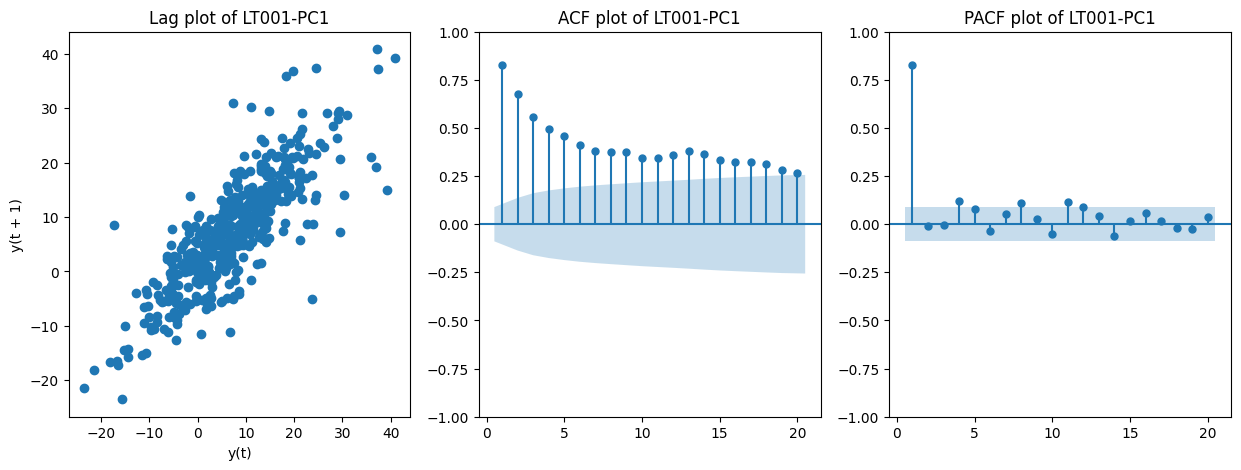

In [ ]:
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.seasonal import seasonal_decompose 
from pandas.plotting import lag_plot

def autoCorr(TS, freq):
    '''
    Plots lag plot, ACF, and PCAF graphs for residuals of the given frequency of a given fish number
    @ data: the data frame
    @ freq: the frequency of the data
    @ fishNum: the fish number 
    return: None
    Side Effect: plots the graphs
    '''
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # lag plot
    lag_plot(TS, ax=ax1)
    ax1.set_title('Lag plot of '+ freq)
    
    # ACF plot
    sgt.plot_acf(TS, lags=20, zero=False, ax=ax2)
    ax2.set_title('ACF plot of '+ freq)

    # PACF plot
    sgt.plot_pacf(TS, lags=20, zero=False, ax=ax3)
    ax3.set_title('PACF plot of '+ freq)

    fig.show()

autoCorr(Z.loc[identifiers.fishNum == "LT001", 0], "LT001-PC1")

fishNum: BUR001
fishNum: LT010


C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarni

fishNum: LWF004
fishNum: SMB002


C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\86139\AppData\Local\Temp\ipykernel_6660\3733380488.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


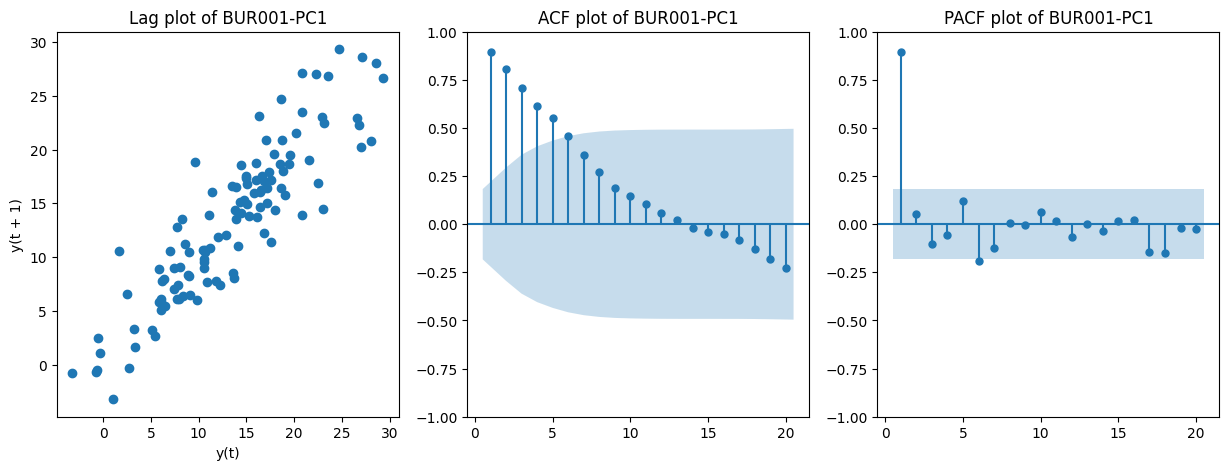

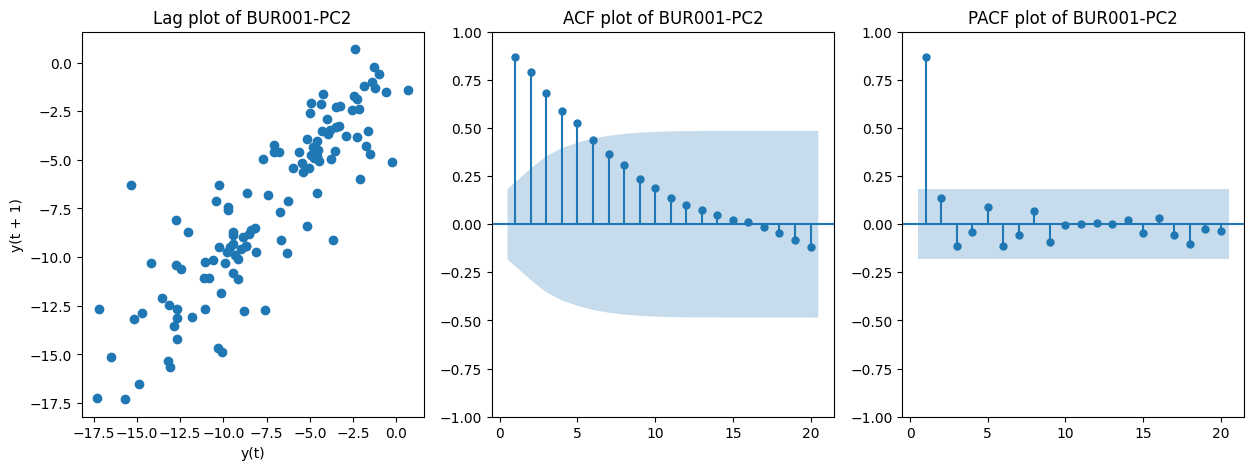

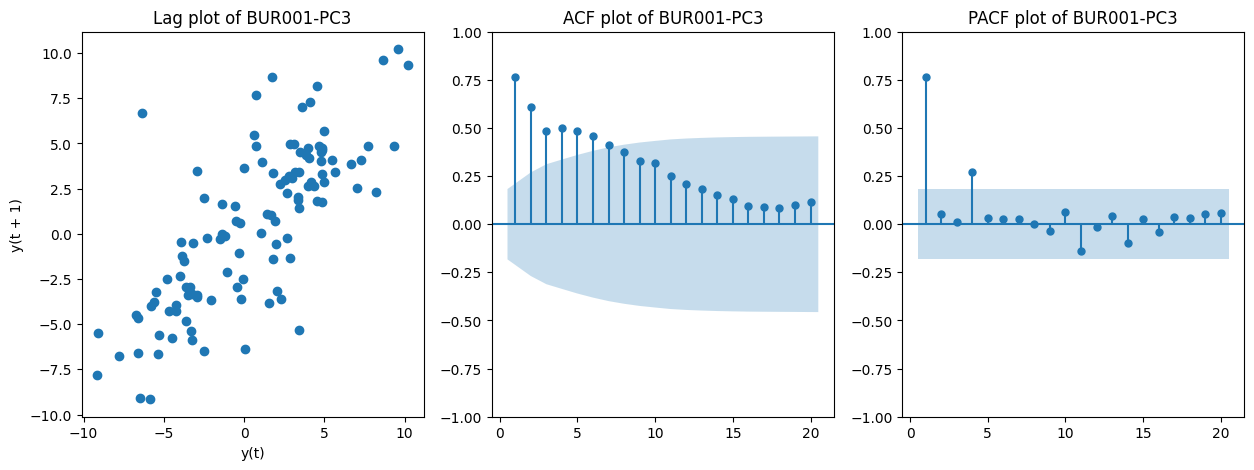

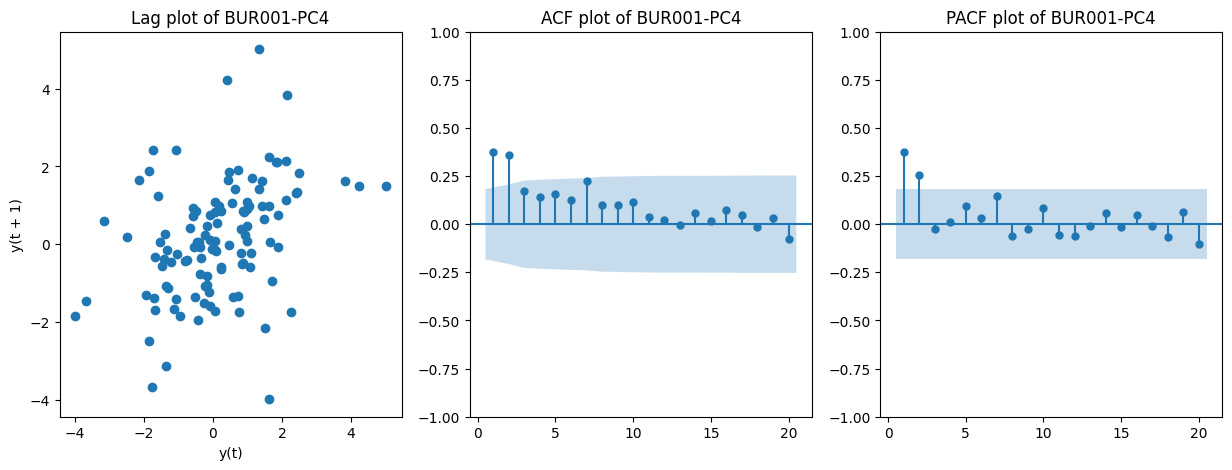

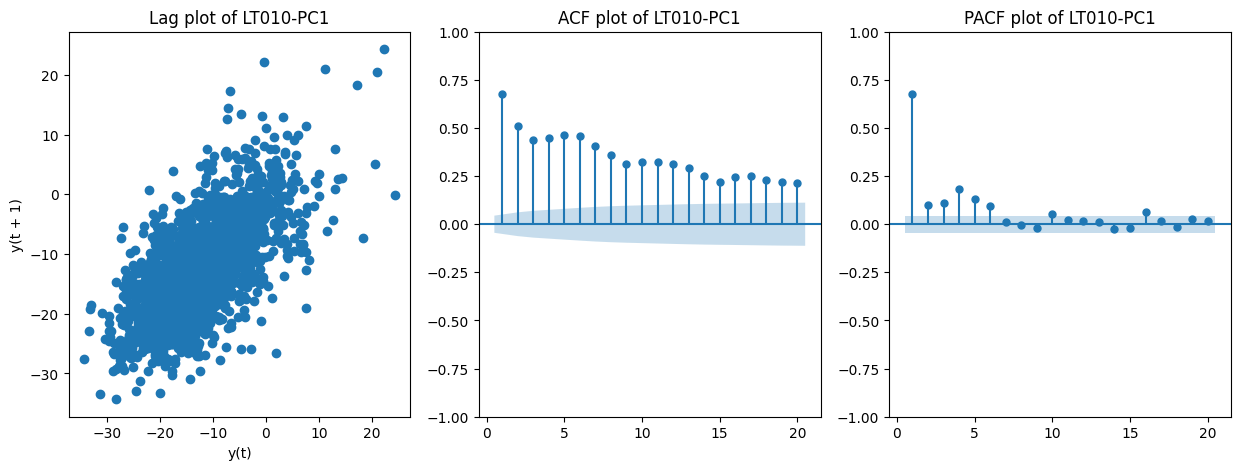

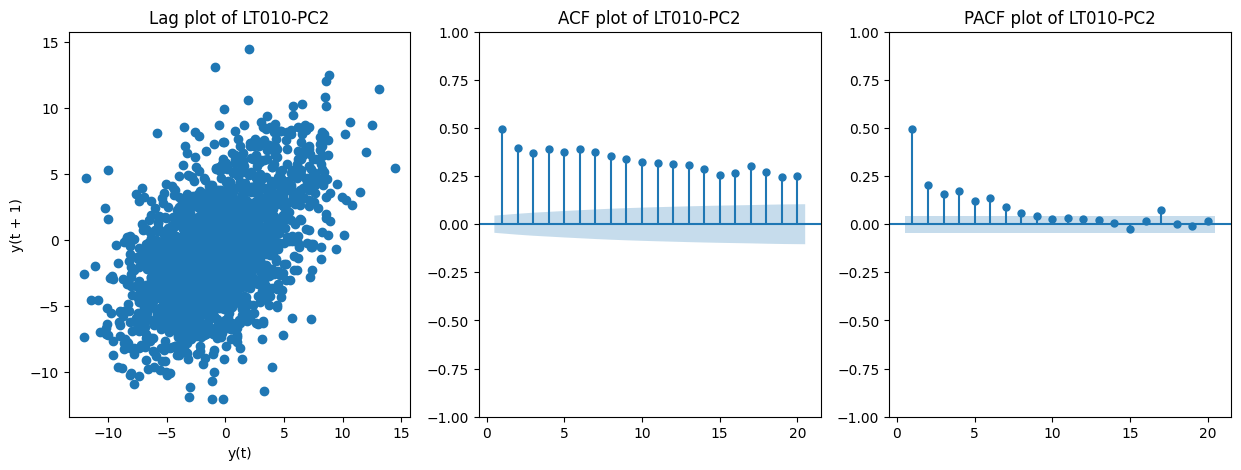

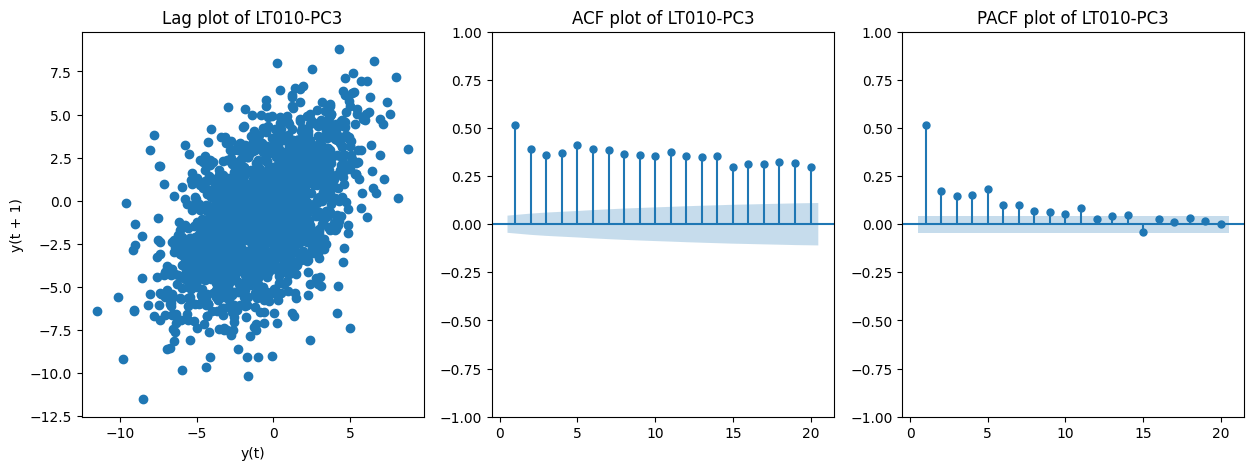

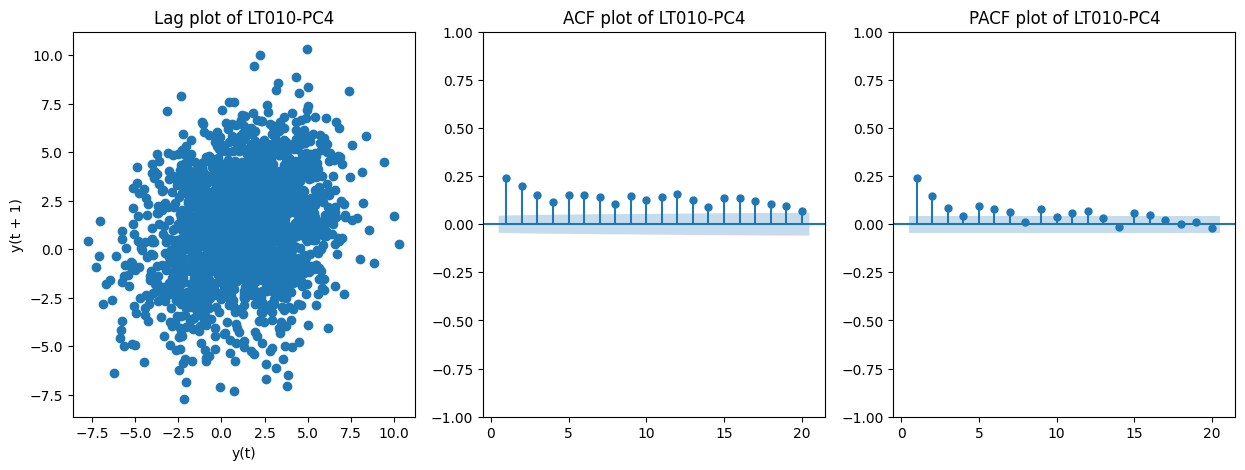

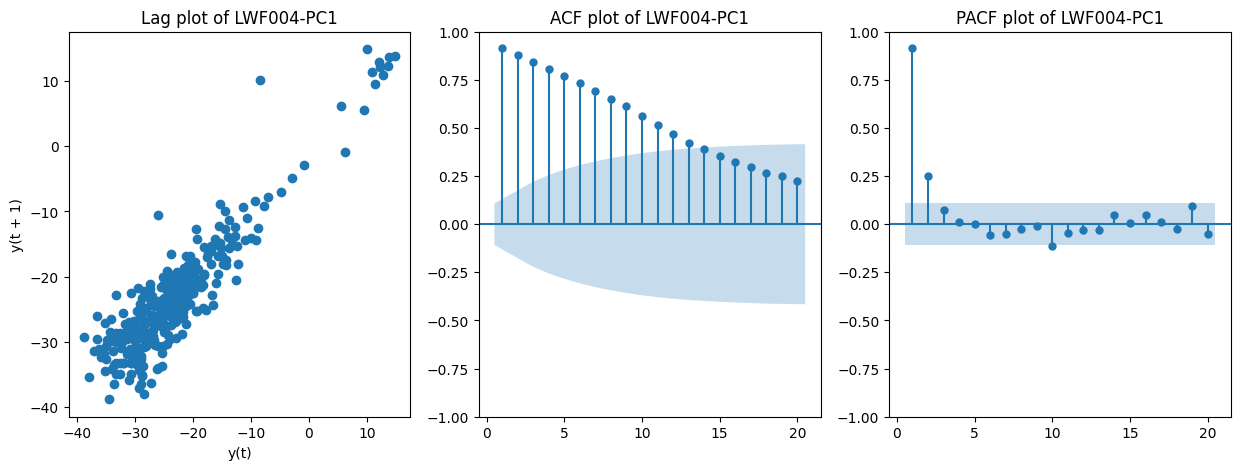

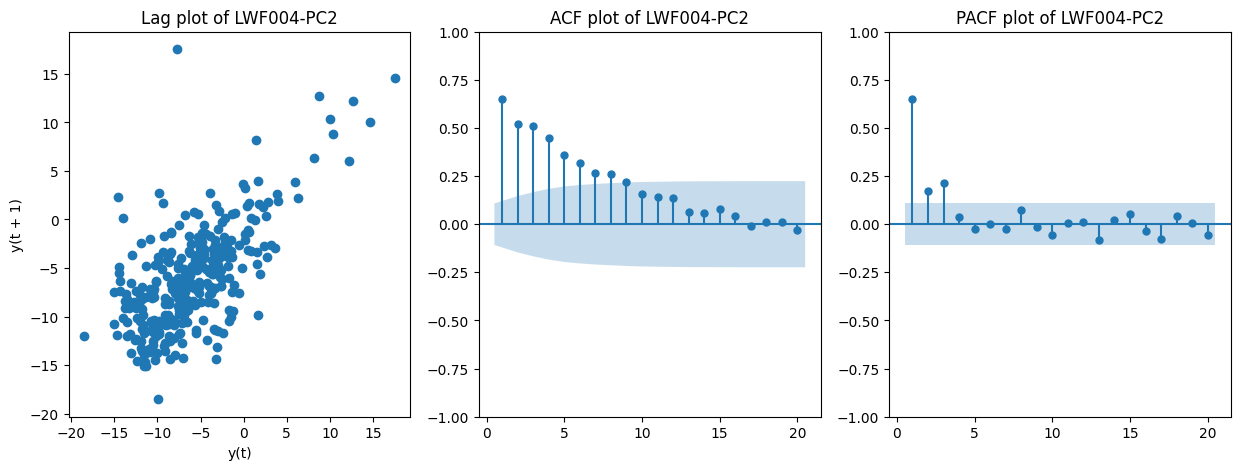

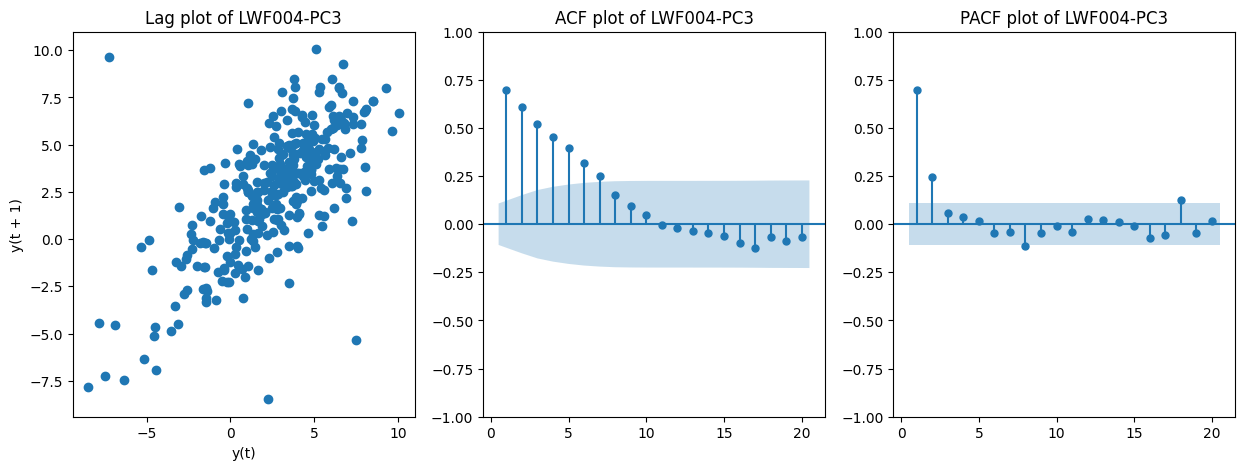

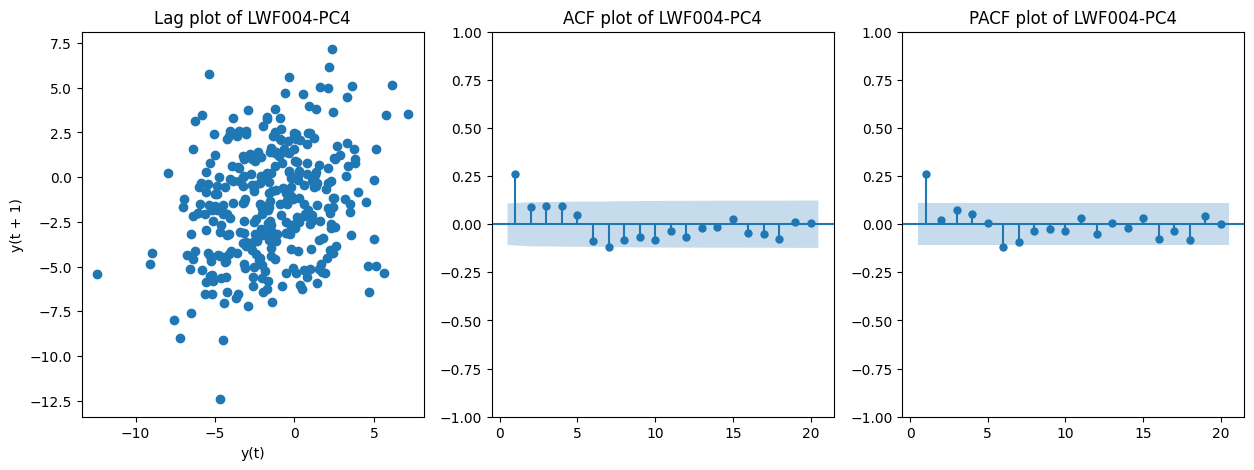

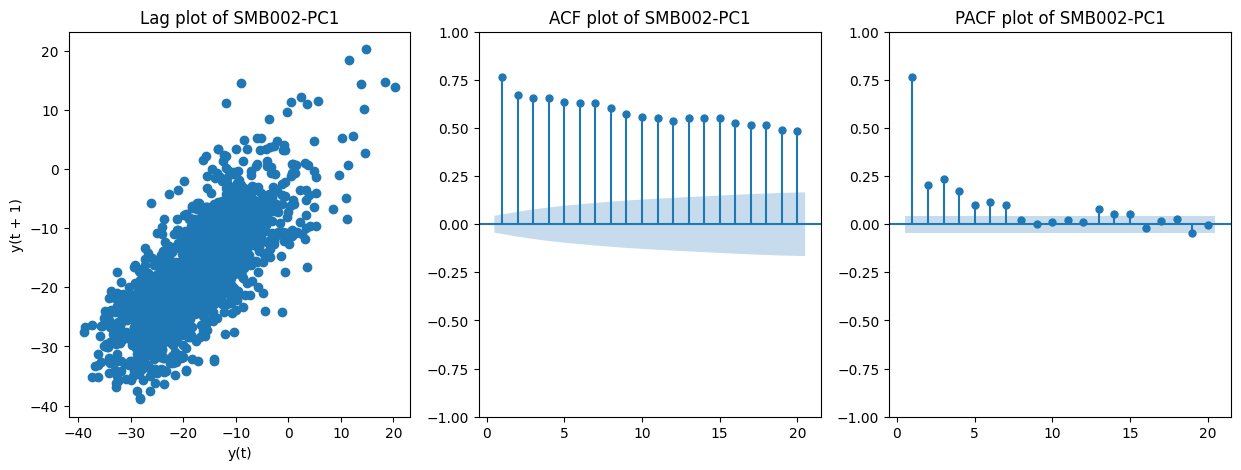

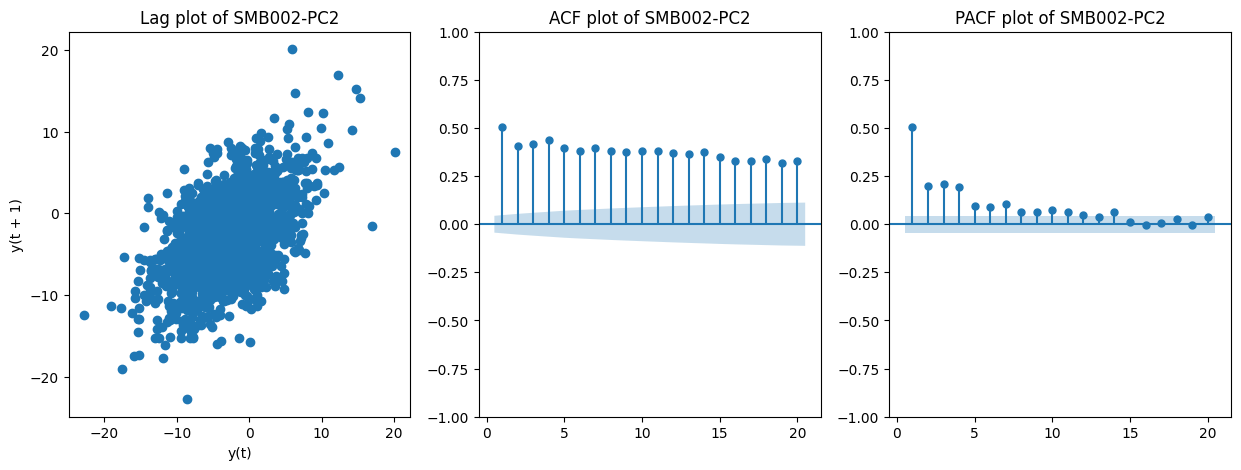

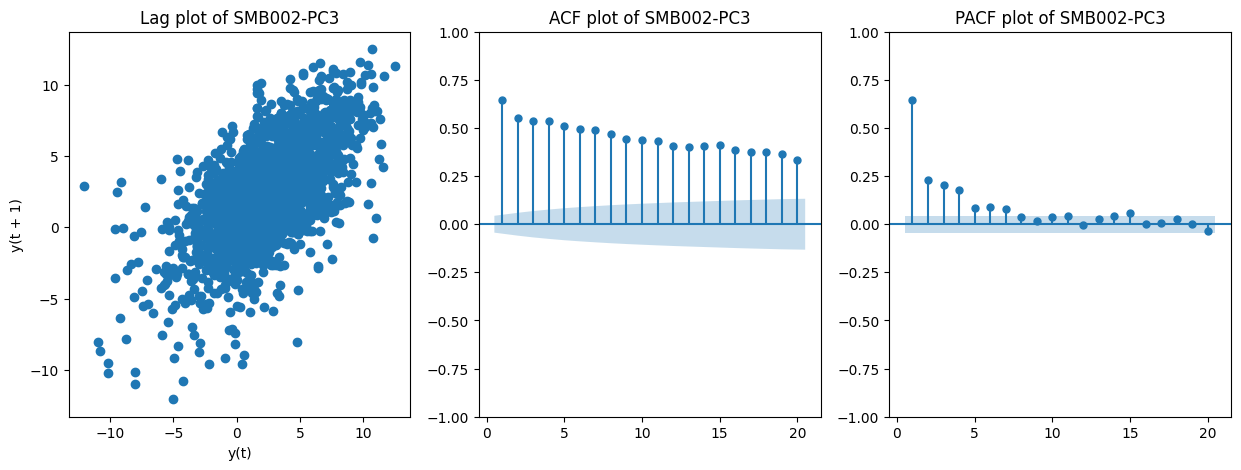

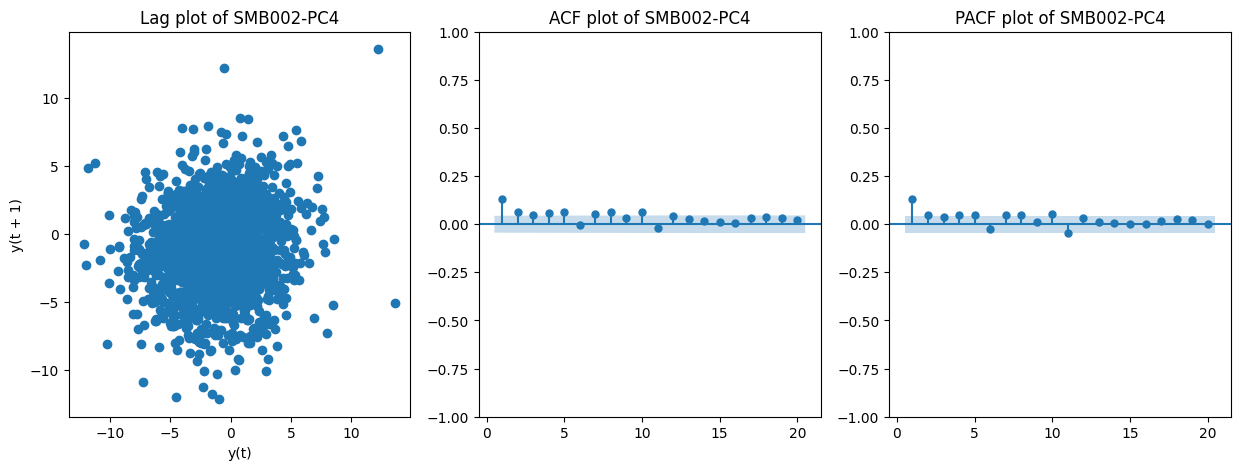

In [ ]:
uniqueFishNum = identifiers.groupby("species").fishNum.unique()
rndFishNum = np.random.choice(uniqueFishNum, size=4, replace=False)
rndPC = list(range(0,4))


for k in dict(uniqueFishNum).keys():
    np.random.seed(np.random.randint(0, 1000))
    fishNum = np.random.choice(uniqueFishNum[k], size=1, replace=False)[0]
    print(f'fishNum: {fishNum}')
    for j in rndPC:
        autoCorr(Z.loc[identifiers.fishNum == fishNum, j], f'{fishNum}-PC{j+1}')

For BUR, LT, and LWF, autocorrelation usually lag 1, seldom exceed 2.
For SMB, autocorrelation usually exceed 2
Tracing PCs are more likely to have autocorrelation more than 2.

## Fitting HMM to Reduced Data

In [ ]:
for k in dict(uniqueFishNum).keys():
    np.random.seed(np.random.randint(0, 1000))
    fishNum = np.random.choice(uniqueFishNum[k], size=1, replace=False)[0]
    print(f'fishNum: {fishNum}')
    for j in rndPC:
        sgt.plot_pacf(np.diff(Z.loc[identifiers.fishNum == fishNum, j], 1), lags=20, zero=False)
        plt.title(f'{fishNum}-PC{j+1}')
        plt.show()

After 1-st order differencing, some PACF varnishes, but some remains in SMB especially.

In [ ]:
lengthsByFish = identifiers.groupby("fishNum").size().tolist()
lengthsBySpcies = identifiers.groupby("species").size().tolist()
n = sum(lengthsByFish)

meanVar = Z.agg([np.mean, np.var], axis=0).T.rename(
    columns={"mean": "Mean", "var": "Var"}).reset_index()
covars = meanVar["Var"]

NameError: name 'Z' is not defined

In [47]:
model_1 = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=1000, tol=0.01)
model_1.startprob_ = np.array(lengthsBySpcies)/n
model_1.transmat_ = np.array([[0.2, 0.2, 0.3, 0.3],
                            [0.3, 0.2, 0.2, 0.3],
                            [0.2, 0.3, 0.3, 0.2],
                            [0.3, 0.3, 0.2, 0.2]])

model_1.means_prior = np.array(
    [np.zeros(30) for i in range(4)]
)
model_1.covars_ = np.array(
    [covars for i in range(4)]
)
model_1.fit(Z, lengths=lengthsByFish)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


GaussianHMM(means_prior=array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
            n_components=4, n_iter=1000)

In [48]:
print("HMM parameters of model_1: 30 score features, Gaussian Mixture diagonal, before differencing")
print("Intial distributions: ", model_1.startprob_)
print("Transition matrix:", model_1.transmat_)
print("Mean values:", model_1.means_)
print("Covariances:", model_1.covars_)
print("BIC:", model_1.bic(Z, lengths=lengthsByFish))
print("AIC:", model_1.aic(Z, lengths=lengthsByFish))

HMM parameters of model_1: 30 score features, Gaussian Mixture diagonal, before differencing
Intial distributions:  [0.25437108 0.32654854 0.17416317 0.24491721]
Transition matrix: [[8.66887486e-01 1.56713869e-03 1.31190591e-01 3.54784724e-04]
 [1.73075137e-03 9.76479752e-01 2.48830700e-04 2.15406659e-02]
 [2.64459043e-01 1.43724369e-03 7.34103714e-01 9.36340970e-17]
 [1.07466182e-04 1.60730210e-02 9.37678039e-05 9.83725745e-01]]
Mean values: [[ 1.55569642e+00 -3.40228333e-01  1.88788672e+00 -3.91541770e-01
   7.92720398e-01  3.58567331e-01 -1.49735314e-01 -1.60583373e-01
  -5.47126071e-03  3.67480297e-02 -1.06752085e-01  4.21664249e-02
  -1.64491544e-01  1.65930547e-01  1.21727352e-01  2.51591953e-01
  -2.21366826e-02 -3.25326635e-01  2.54123183e-02  1.26423443e-01
   6.49240702e-02 -4.46507907e-02  2.03981518e-01 -7.07065898e-02
  -1.45501433e-01  9.07433347e-02  6.08719089e-02 -8.04813043e-02
  -1.74963417e-02  1.34176732e-01]
 [ 8.01183802e+00  4.17596728e+00 -2.63629411e+00 -9.394

In [45]:
def permuteSpecies(model, Z, lengthsByFish, actualSpecies):
    """
    Permute the estimated species labels at each time point find the species assignment that maximizes accuracy
    """
    ## Compute the estimated state sequence on the training dataset
    stateHat = model.predict(Z, lengths=lengthsByFish).tolist()

    for m in range(0,4):
        fishMap = {m%4:'burbot', (m+1)%4:'laketrout', (m+2)%4:'lakeWhitefish', (m+3)%4:'smallmouthBass'}
        print("State-Species mapping: ", fishMap)
        speciesHat = [fishMap[state] for state in stateHat]

        ## Compute the estimated probability for each fish based on the prediction
        identifiers["speciesHat"] = speciesHat
        ## For each fish, compute the proportion of being in each species
        speciesHatCount = identifiers.groupby(["fishNum", "speciesHat"]).size().unstack().fillna(0)
        speciesHatProp = speciesHatCount.div(speciesHatCount.sum(axis=1), axis=0).reset_index("fishNum")
        finalSpeciesHat = speciesHatProp.apply(lambda x: x.loc[["burbot","lakeWhitefish","laketrout","smallmouthBass"]].idxmax(), axis=1).tolist()

        actalSpecies = actualSpecies.groupby("fishNum")["species"].first().tolist()
        speciesCompare = pd.DataFrame({"actual": actalSpecies, 
                                       "predicted": finalSpeciesHat})
        accuracy = np.mean(speciesCompare["actual"] == speciesCompare["predicted"])
        print("Accuracy: ", round(accuracy*100, 2), "%\n")

# permuteSpecies(model_1, Z, lengthsByFish, identifiers)

## Try Out Imputation by 0 and Sparse PCA

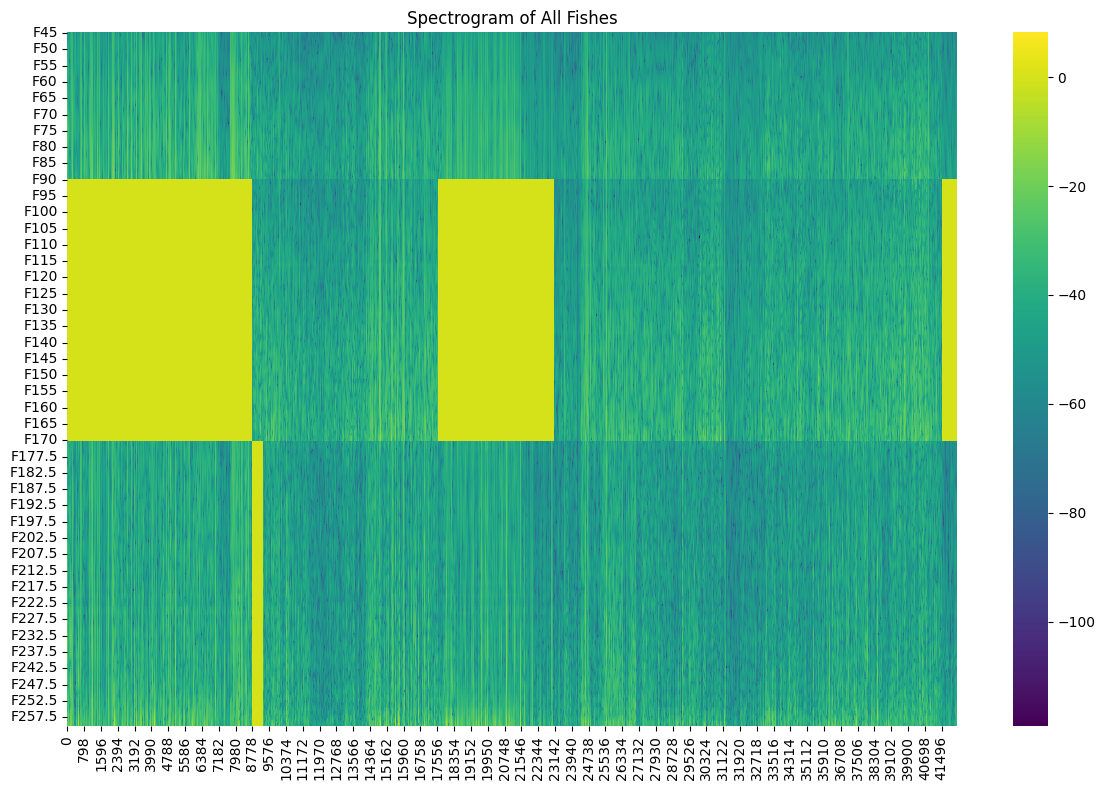

In [15]:
## Plot the spectrogram of all species
import seaborn as sns
X_zeroImp = X.fillna(0)

def spectrogram(df, saveFig=True, n=1000):
    """
    Function to plot the spectrogram (or heatmap) of the fish's target strength in the first n observations
    Args:
        df: DataFrame with the audio file paths
        fishNum: Fish number to plot the spectrogram
        saveFig: Boolean to save the figure
    Returns:
        None
    """
    df.reset_index(drop=True, inplace=True)
    # Create the spectrogram
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.T, cmap="viridis") 
    plt.title('Spectrogram of All Fishes')
    plt.tight_layout()
    # if saveFig:
    #     plt.savefig('C:\\Users\\86139\\Desktop\\FishTetherExperiment\\Images\\spectrogram_fish_' + str(fishNum) + '.png')
    plt.show()

    return None

spectrogram(X_zeroImp, saveFig=False, n=X.shape[0])

Number of PCs that explain 0.8% of the variance: 4


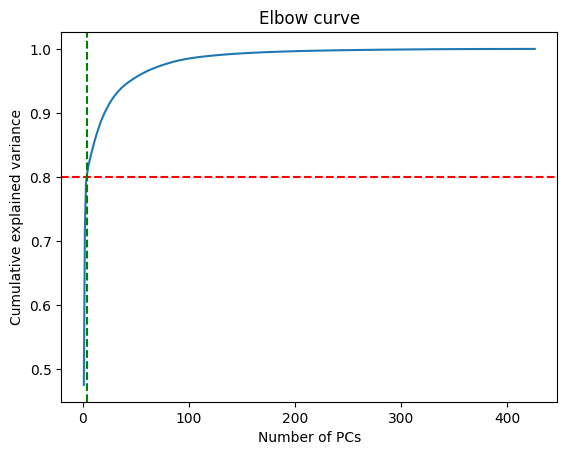

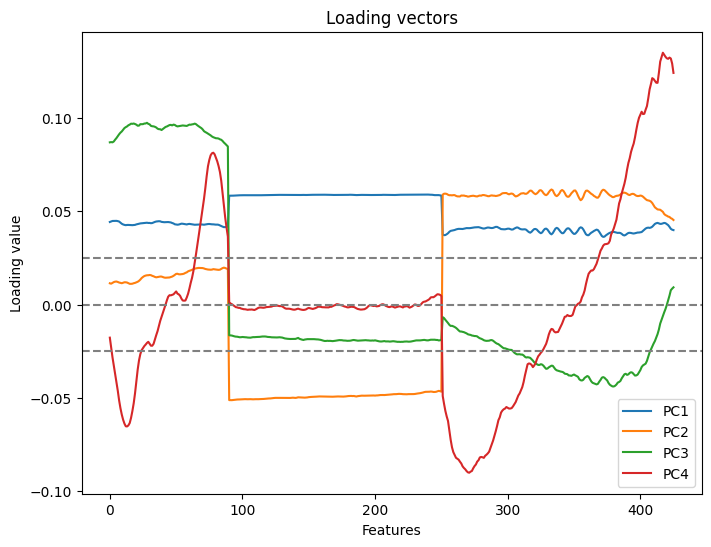

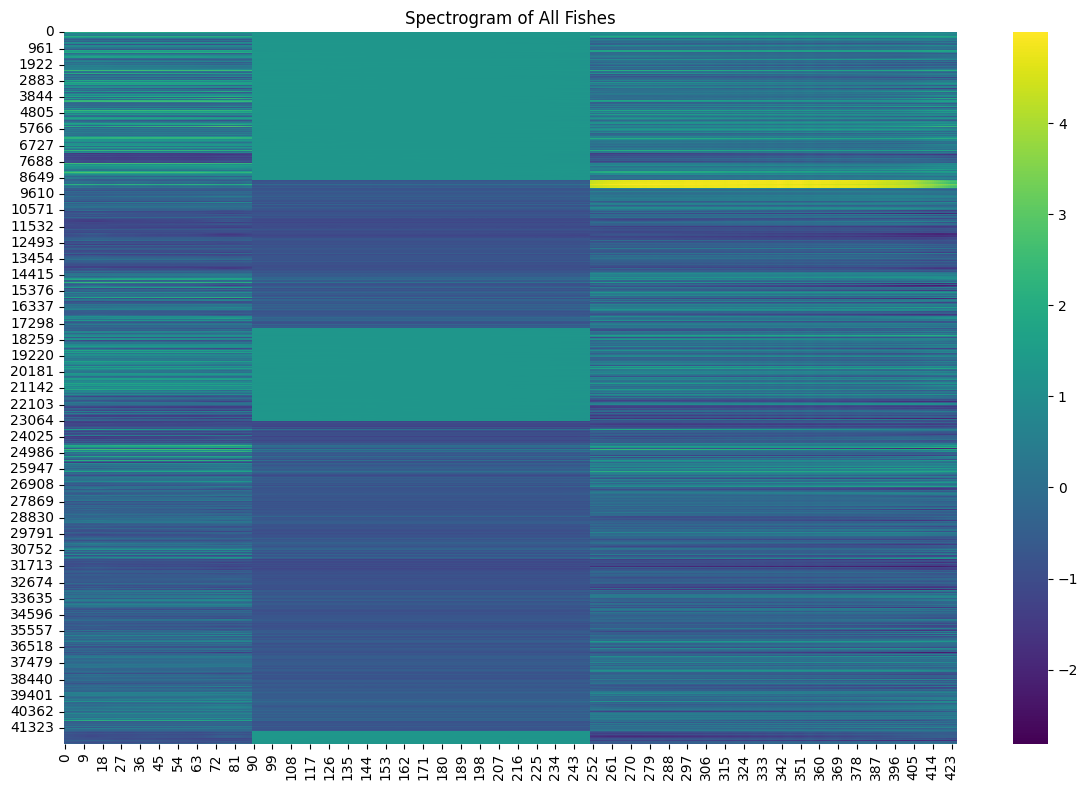

Number of PCs that explain 0.9% of the variance: 21


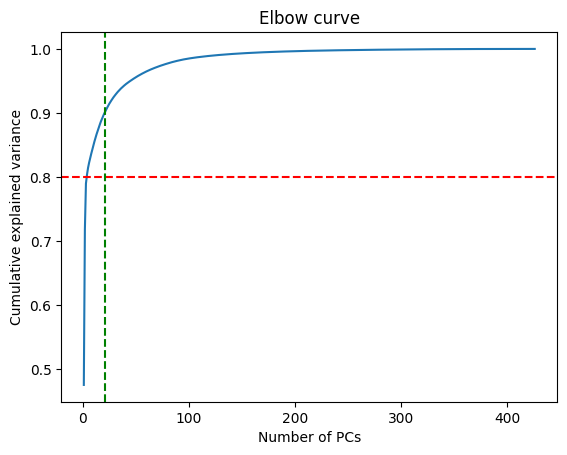

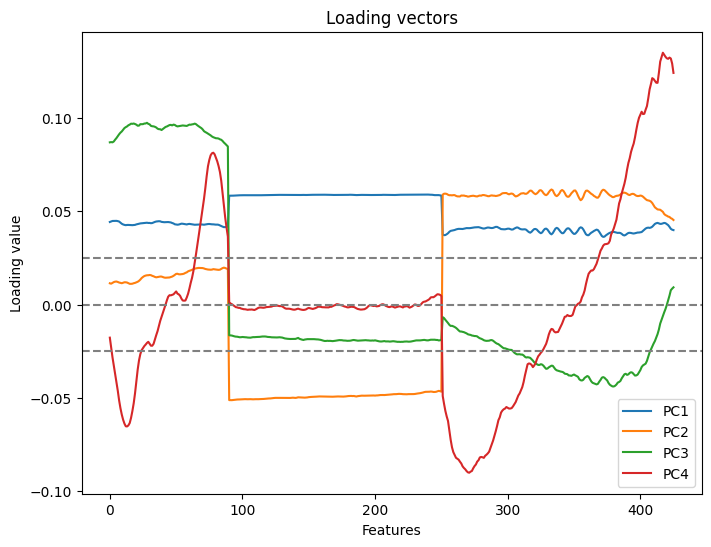

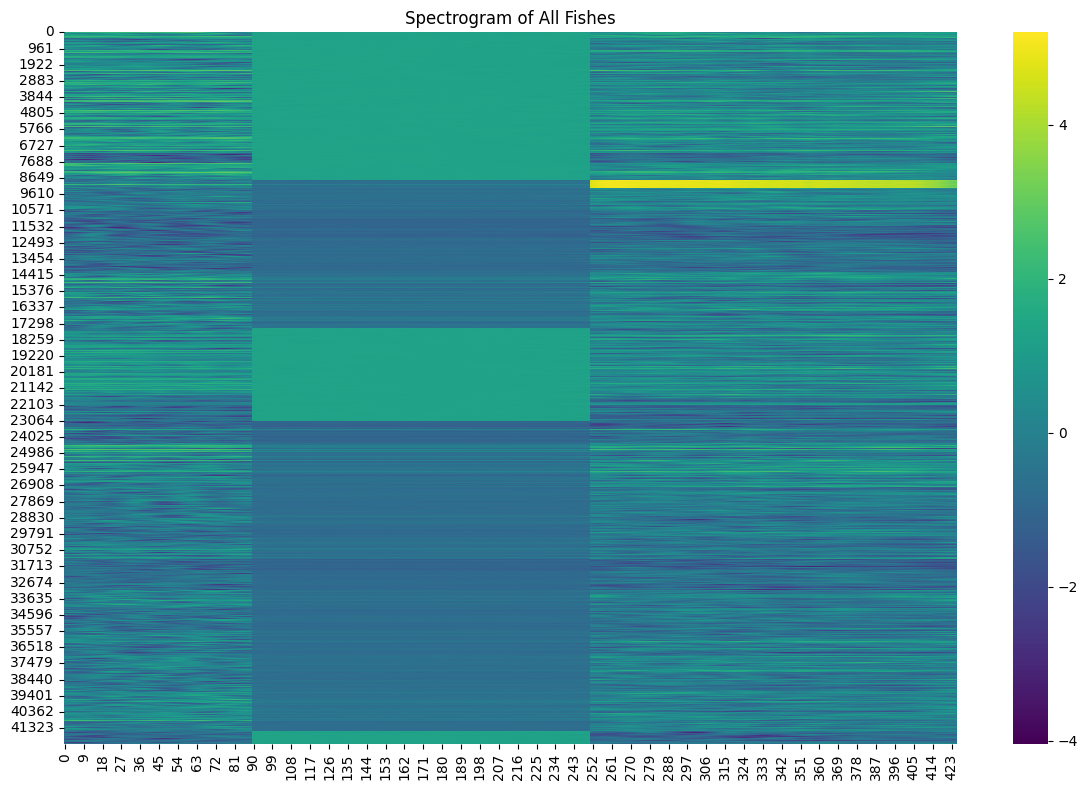

In [93]:
## 2nd version that fills missing values by 
def pca(df, recoveryRate):

    # Fill missing values with the column mean, column by column 
    df = df.fillna(0)

    # Standardize the data
    scaler = StandardScaler()
    df = scaler.fit_transform(df)

    # Perform sparse PCA
    # spca = SparsePCA(n_components=3, alpha=0.01)
    # spca.fit(df)

    # Perform PCA
    pca = PCA()
    pca.fit(df)
    
    # Get the top PCs that explains the 80% of the variance
    varExplained = np.cumsum(pca.explained_variance_ratio_)
    numPCs = np.argmax(varExplained >= recoveryRate) + 1
    print(f"Number of PCs that explain {recoveryRate}% of the variance: {numPCs}")
    V = pca.components_[:numPCs].T
    Z = df @ V

    X_hat = Z @ V.T
    X_hat = pd.DataFrame(X_hat).reset_index(drop=True)

    V = pd.DataFrame(V)
    Z = pd.DataFrame(Z)

    # plot the elbow curve
    import matplotlib.pyplot as plt
    plt.plot(range(1, len(varExplained) + 1), varExplained)
    plt.title('Elbow curve')
    plt.xlabel('Number of PCs')
    plt.ylabel('Cumulative explained variance')
    plt.axhline(y=0.8, color='r', linestyle='--')
    plt.axvline(x=numPCs, color='g', linestyle='--')
    plt.show()

    # Plot the first two loading vectors
    plt.figure(figsize=(8, 6))
    plt.plot(V.iloc[:, 0], label='PC1')
    plt.plot(V.iloc[:, 1],  label='PC2')
    plt.plot(V.iloc[:, 2],  label='PC3')
    plt.plot(V.iloc[:, 3],  label='PC4')
    plt.axhline(y=0, color='grey', linestyle='--')
    plt.axhline(y=-0.025, color='grey', linestyle='--')
    plt.axhline(y=0.025, color='grey', linestyle='--')
    plt.title('Loading vectors') 
    plt.xlabel('Features')
    plt.ylabel('Loading value')
    plt.legend()
    plt.show()

    ## plot the matrix recoverd by the the top PCs
    spectrogram(X_hat, saveFig=False, n=X_hat.shape[0])

    # Return extracted features
    return {"V": V, "Z": Z}


recover80 = pca(X, 0.8)
recover90 = pca(X, 0.9)


Colors of recovered spectrogram are darker than the original one. \\
Colors of spectrogram with more PCs are more fine-grained than the one with lower recovery rate.

Number of PCs that explain 80.0% of the variance: 4


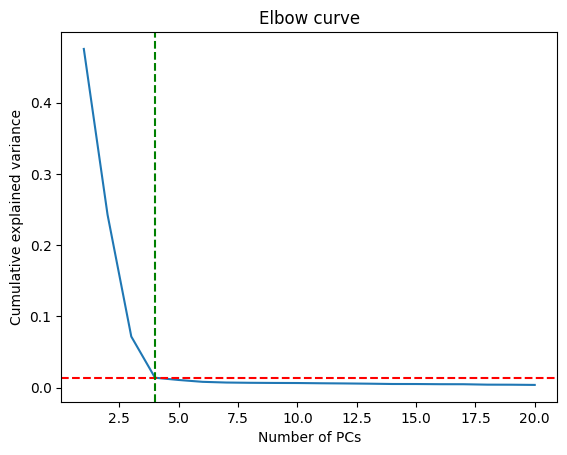

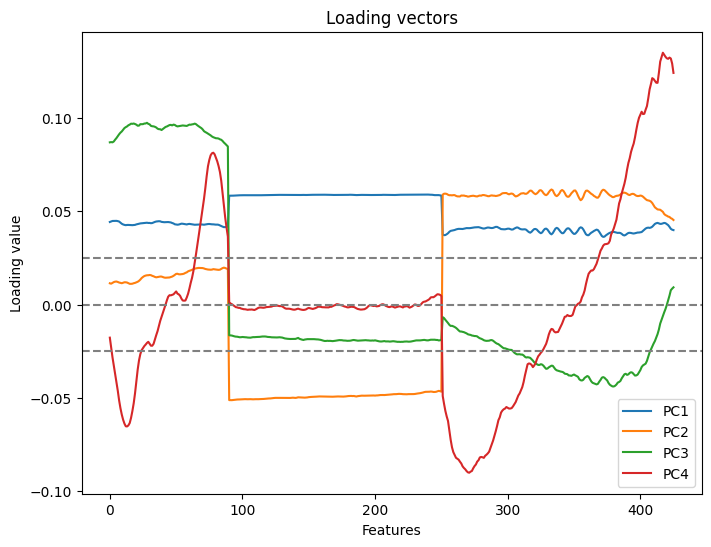

In [ ]:
## Now try truncated SVD to control the number of components
from sklearn.decomposition import TruncatedSVD

def pca(df, recoveryRate, maxComponents=50):
    # Set all NAs values to 0
    df = df.fillna(0)

    # Standardize the data
    scaler = StandardScaler()
    df = scaler.fit_transform(df)

    # SVD dimensionality reduction
    pca = PCA(n_components=maxComponents, random_state=42)
    pca.fit(df)

    # Get the top PCs that explains the 80% of the variance
    varExplained = np.cumsum(pca.explained_variance_ratio_)
    numPCs = np.argmax(varExplained >= recoveryRate) + 1
    print(f"Number of PCs that explain {recoveryRate *100}% of the variance: {numPCs}")

    
    V = pca.components_[:numPCs].T

    V = pd.DataFrame(V)
    # Z = pd.DataFrame(Z)

    # X_hat = Z @ V.T
    # X_hat = pd.DataFrame(X_hat).reset_index(drop=True)
    # spectrogram(X_hat, saveFig=False, n=X_hat.shape[0])

    # plot the elbow curve
    import matplotlib.pyplot as plt
    plt.plot(range(1, len(varExplained) + 1), pca.explained_variance_ratio_)
    plt.title('Elbow curve')
    plt.xlabel('Number of PCs')
    plt.ylabel('Cumulative explained variance')
    plt.axhline(y=pca.explained_variance_ratio_[numPCs-1], color='r', linestyle='--')
    plt.axvline(x=numPCs, color='g', linestyle='--')
    plt.show()

    # Plot the first two loading vectors
    plt.figure(figsize=(8, 6))
    plt.plot(V.iloc[:, 0], label='PC1')
    plt.plot(V.iloc[:, 1],  label='PC2')
    plt.plot(V.iloc[:, 2],  label='PC3')
    plt.plot(V.iloc[:, 3],  label='PC4')
    plt.axhline(y=0, color='grey', linestyle='--')
    plt.axhline(y=-0.025, color='grey', linestyle='--')
    plt.axhline(y=0.025, color='grey', linestyle='--')
    plt.title('Loading vectors') 
    plt.xlabel('Features')
    plt.ylabel('Loading value')
    plt.legend()
    plt.show()

    # Return extracted features
    return V

recover80 = pca(X, 0.8, 20)

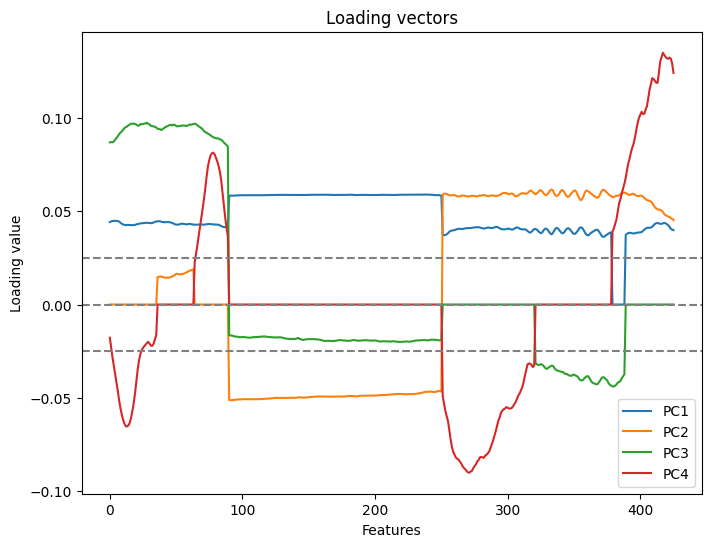

In [60]:
## Hard thresholding on loading vectorsb
def hard_threshold(components, sparsity=0.2):
    """Set all but the top (sparsity*100)% values to zero in each PC."""
    threshold = np.percentile(
        np.abs(components), 
        100 * (1 - sparsity),  # Percentile cutoff (e.g., 80th for 20% sparsity)
        axis=1, 
        keepdims=True
    )
    return components * (np.abs(components) >= threshold)

V = recover80
V = hard_threshold(V, sparsity=0.9)

plt.figure(figsize=(8, 6))
plt.plot(V.iloc[:, 0], label='PC1')
plt.plot(V.iloc[:, 1],  label='PC2')
plt.plot(V.iloc[:, 2],  label='PC3')
plt.plot(V.iloc[:, 3],  label='PC4')
plt.axhline(y=0, color='grey', linestyle='--')
plt.axhline(y=-0.025, color='grey', linestyle='--')
plt.axhline(y=0.025, color='grey', linestyle='--')
plt.title('Loading vectors') 
plt.xlabel('Features')
plt.ylabel('Loading value')
plt.legend()
plt.show()

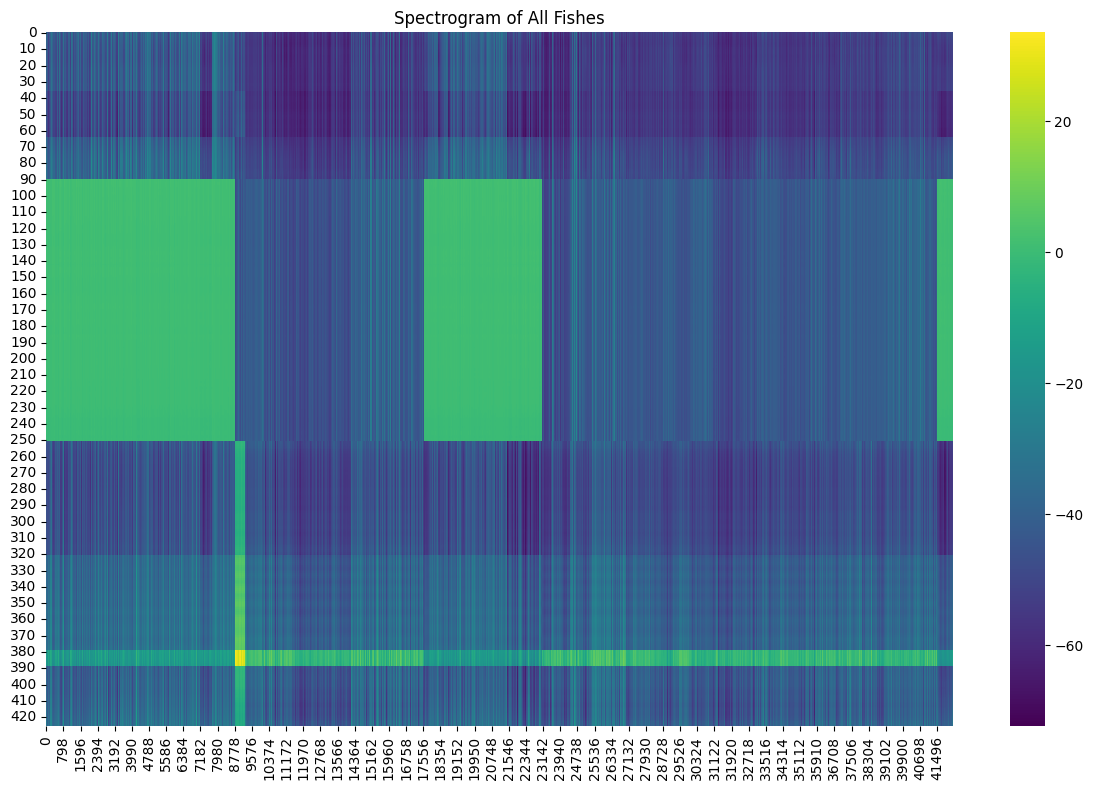

In [ ]:
X = np.array(X_zeroImp)
X_hat = X @ V @ V.T
spectrogram(X_hat, saveFig=False, n=X_hat.shape[0])

## Re-run HMM on the Reduced Data

In [58]:
lengthsByFish = identifiers.groupby("fishNum").size().tolist()
lengthsBySpcies = identifiers.groupby("species").size().tolist()
n = sum(lengthsByFish)

Z_hat = X @ V
# meanVar = Z_hat.agg([np.mean, np.var], axis=0).T.rename(
#     columns={"mean": "Mean", "var": "Var"}).reset_index()
# covars = meanVar["Var"]

model_1 = hmm.GaussianHMM(n_components=4, covariance_type="tied", n_iter=1000, tol=0.01)
# model_1.startprob_ = np.array(lengthsBySpcies)/n
# model_1.transmat_ = np.array([[0.2, 0.2, 0.3, 0.3],
                            # [0.3, 0.2, 0.2, 0.3],
                            # [0.2, 0.3, 0.3, 0.2],
                            # [0.3, 0.3, 0.2, 0.2]])

# model_1.means_prior = np.array(
#     [np.zeros(4) for i in range(4)]
# )
# model_1.covars_ = np.array(
#     [covars for i in range(4)]
# )


model_1.fit(Z_hat, lengths=lengthsByFish)
print("HMM parameters of model_1: 30 score features, Gaussian Mixture diagonal, before differencing")
print("Intial distributions: ", model_1.startprob_)
print("Transition matrix:", model_1.transmat_)
print("Mean values:", model_1.means_)
print("Covariances:", model_1.covars_)
print("BIC:", model_1.bic(Z_hat, lengths=lengthsByFish))
print("AIC:", model_1.aic(Z_hat, lengths=lengthsByFish))

permuteSpecies(model_1, Z_hat, lengthsByFish, identifiers)

HMM parameters of model_1: 30 score features, Gaussian Mixture diagonal, before differencing
Intial distributions:  [0.209537   0.42857143 0.03571429 0.32617728]
Transition matrix: [[0.98198887 0.         0.         0.01801113]
 [0.         1.         0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.02802968 0.         0.         0.97197032]]
Mean values: [[-951.92171534 -155.29730234 -148.47573839   33.10034609]
 [-446.38270403 -457.60867747 -236.10328985   38.36367604]
 [-569.09568841  310.37675161 -254.98268642    5.14968367]
 [-820.55515037 -151.27006536 -130.1646315    40.64461644]]
Covariances: [[[4959.76949399 2827.34452553 1114.59129829  187.82655617]
  [2827.34452553 3406.6210134   369.17015432  210.67489869]
  [1114.59129829  369.17015432 1513.45978259  -86.23307812]
  [ 187.82655617  210.67489869  -86.23307812  520.6203367 ]]

 [[4959.76949399 2827.34452553 1114.59129829  187.82655617]
  [2827.34452553 3406.6210134   369.17015432  210.67489869]
  [11

C:\Users\86139\AppData\Local\Temp\ipykernel_27232\1579128852.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  identifiers["speciesHat"] = speciesHat
C:\Users\86139\AppData\Local\Temp\ipykernel_27232\1579128852.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  identifiers["speciesHat"] = speciesHat
C:\Users\86139\AppData\Local\Temp\ipykernel_27232\1579128852.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

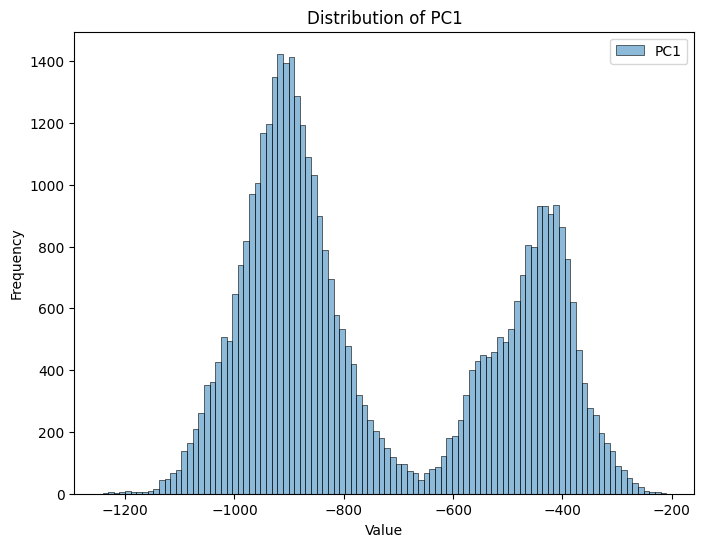

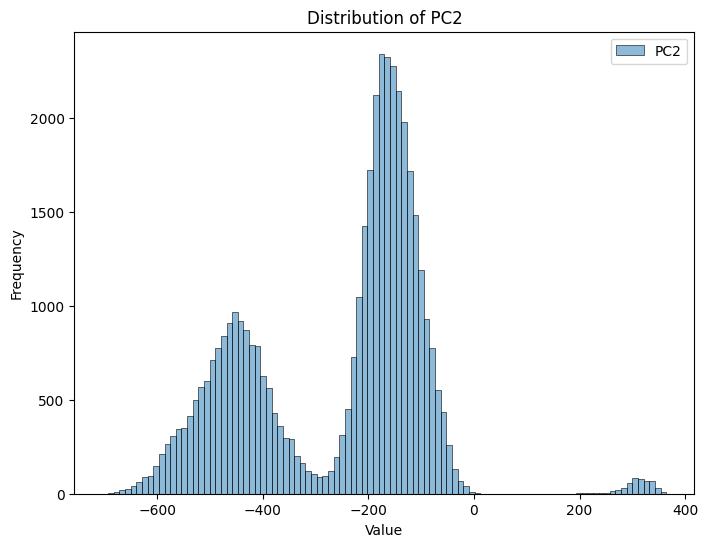

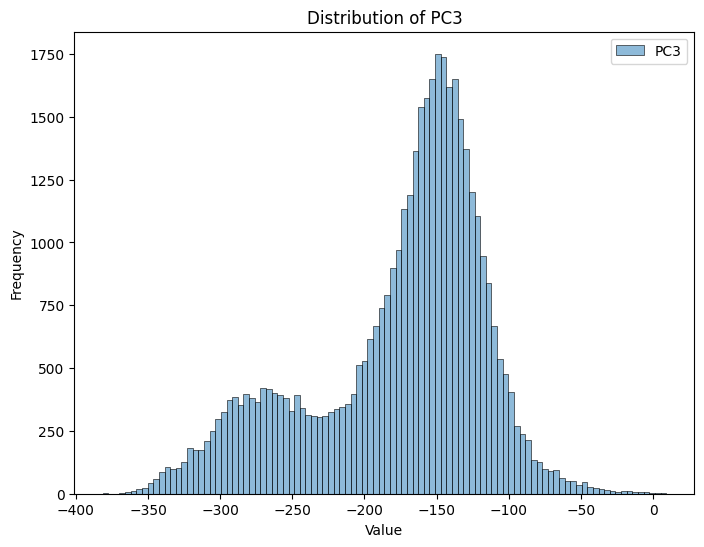

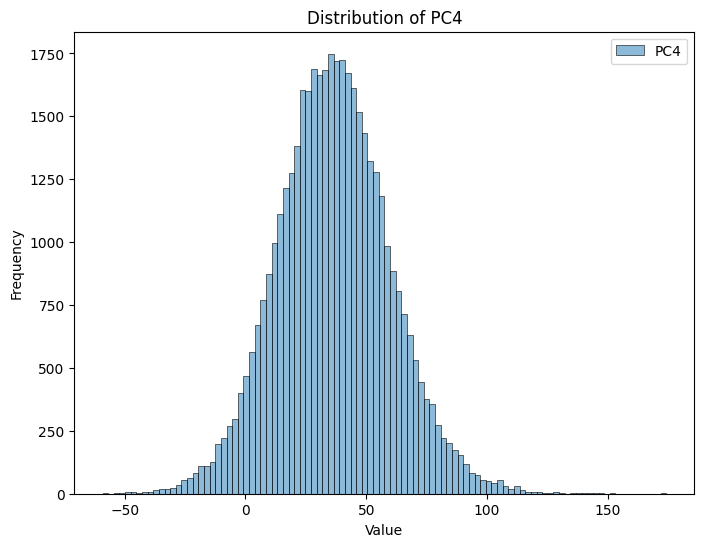

In [56]:
## Inspect mixture gaussian distribution

for j in range(0,4):
    plt.figure(figsize=(8, 6))
    sns.histplot(Z_hat.iloc[:, j], bins=100, alpha=0.5, label=f'PC{j+1}')
    plt.title(f'Distribution of PC{j+1}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()

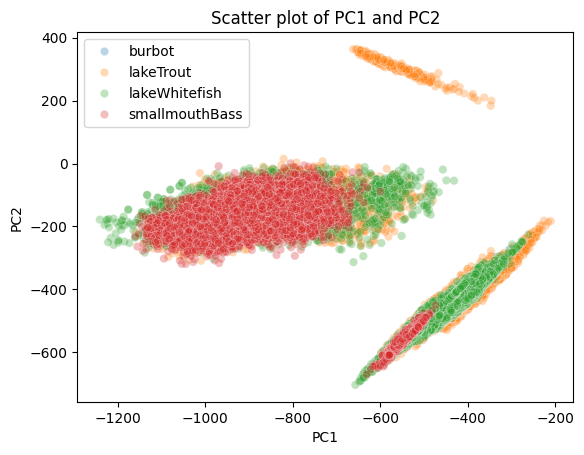

In [63]:
plt.Figure(figsize=(8, 6))
sns.scatterplot(x=Z_hat.iloc[:, 0], y=Z_hat.iloc[:, 1], hue=identifiers["species"], alpha=0.3)
plt.title('Scatter plot of PC1 and PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()